# 01 · ETL Distribuido — Sentinel-2
**Proyecto:** GeoVisionCLIP-Cali  
**Fase:** 1 — Ingesta y Preprocesamiento Masivo (Dask + Rasterio → Zarr)  
**Hardware objetivo:** Windows 11 · 32 GB RAM · RTX 3050 6 GB VRAM  

---
### Descripción del Pipeline
1. Inicializar clúster `Dask` local con límites estrictos de memoria.
2. Parsear `manifest_sentinel2.json` para obtener rutas y metadatos.
3. Leer bandas **B02, B03, B04, B08** con `rasterio`.
4. Reescalar cada tile a **224 × 224 px**, apilar bandas y normalizar con stats de **GeoRSCLIP**.
5. Persistir el resultado como almacén **Zarr** en `D:\analitica\procesado_zarr\sentinel2_224.zarr`.
6. Trazabilidad visual: imprimir 5 recortes RGB de muestra.

> ⚠️ **Prohibido procesamiento single-thread.** Dask maneja todo el I/O de los ~300 GB.

## 0 · Dependencias

In [ ]:
# ── Instalación (ejecutar solo 1 vez, luego comentar) ──────────────────────
#!pip install dask[distributed] dask[array] rasterio zarr numcodecs matplotlib tqdm pyproj shapely
# ──────────────────────────────────────────────────────────────────────────

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/6.3 MB ? eta -:--:--
   -------- ------------------------------- 1.3/6.3 MB 7.4 MB/s eta 0:00:01
   ------------------ --------------------- 2.9/6.3 MB 8.0 MB/s eta 0:00:01
   -------------------------- ------------- 4.2/6.3 MB 8.1 MB/s eta 0:00:01
   ----------------------------------- ---- 5.5/6.3 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 6.3/6.3 MB 6.1 MB/s  0:00:01
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------------ --------------------- 0.8/1.7 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 4.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [shapely]
   -------------------- ------------------- 1/2 [pyproj]
   -------------------- ------------------- 1/2 [pyproj]
   ---------------------------------------- 2/2 [pyproj]



In [22]:
import json
import os
import hashlib
from pathlib import Path
from typing import List, Dict, Tuple

import numpy as np
import zarr
import rasterio
from rasterio.enums import Resampling
from rasterio.transform import from_bounds

import dask
import dask.array as da
from dask.distributed import Client, LocalCluster, progress

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm.auto import tqdm

print(f"NumPy  : {np.__version__}")
print(f"Zarr   : {zarr.__version__}")
print(f"Dask   : {dask.__version__}")
print(f"Rasterio: {rasterio.__version__}")

NumPy  : 2.2.6
Zarr   : 2.18.3
Dask   : 2026.3.0
Rasterio: 1.4.4


## 1 · Configuración Global

In [23]:
# ─── Rutas ────────────────────────────────────────────────────────────────
SENTINEL2_ROOT   = Path(r"D:\analitica\sentinel2")
MANIFEST_PATH    = SENTINEL2_ROOT / "manifest_sentinel2.json"
ZARR_OUTPUT_PATH = Path(r"D:\analitica\procesado_zarr\sentinel2_224.zarr")

# ─── Bandas objetivo ──────────────────────────────────────────────────────
TARGET_BANDS = ["B02", "B03", "B04", "B08"]   # Blue, Green, Red, NIR
N_BANDS      = len(TARGET_BANDS)
TILE_SIZE    = 224   # resolución canónica CLIP

# ─── Normalización GeoRSCLIP / RemoteCLIP ─────────────────────────────────
# Estadísticas estándar del backbone (escala 0-1 antes de aplicar)
CLIP_MEAN = np.array([0.48145466, 0.4578275,  0.40821073], dtype=np.float32)  # R,G,B
CLIP_STD  = np.array([0.26862954, 0.26130258, 0.27577711], dtype=np.float32)
# Para NIR usaremos la media/std estimada del dominio remoto (banda independiente)
NIR_MEAN  = 0.3
NIR_STD   = 0.15

# ─── Dask ─────────────────────────────────────────────────────────────────
N_WORKERS      = 4
THREADS_WORKER = 2
MEM_LIMIT      = "6GB"   # 4 workers × 6 GB = 24 GB → deja 8 GB libres en 32 GB RAM

print("Configuración lista.")
print(f"  Origen S2  : {SENTINEL2_ROOT}")
print(f"  Salida Zarr: {ZARR_OUTPUT_PATH}")
print(f"  Workers    : {N_WORKERS} × {MEM_LIMIT}")

Configuración lista.
  Origen S2  : D:\analitica\sentinel2
  Salida Zarr: D:\analitica\procesado_zarr\sentinel2_224.zarr
  Workers    : 4 × 6GB


## 2 · Inicializar Clúster Dask

In [4]:
cluster = LocalCluster(
    n_workers=N_WORKERS,
    threads_per_worker=THREADS_WORKER,
    memory_limit=MEM_LIMIT,
    dashboard_address=":8787",   # http://localhost:8787
)
client = Client(cluster)
print(client)
print(f"\nDashboard Dask → {client.dashboard_link}")

<Client: 'tcp://127.0.0.1:56349' processes=4 threads=8, memory=22.35 GiB>

Dashboard Dask → http://127.0.0.1:8787/status


## 3 · Parsear Manifest Sentinel-2

In [10]:
def load_manifest(manifest_path: Path) -> List[Dict]:
    """
    Carga manifest_sentinel2.json y devuelve una lista de registros
    agrupados por escena, filtrando solo las bandas TARGET_BANDS.
    """
    with open(manifest_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    print(type(raw))

    if isinstance(raw, dict):
        print(raw.keys())

    elif isinstance(raw, list):
        print(f"Lista con {len(raw)} elementos")
        print(raw[0] if len(raw) > 0 else "vacío")


    # ── El manifest puede ser lista de registros o dict con clave 'escenas' ──
    #records = raw if isinstance(raw, list) else raw.get("escenas", raw.get("tiles", []))
    if isinstance(raw, list):
        records = raw
    else:
        records = raw.get("archivos", [])

    print(records[0])

    # Agrupar por escena_id
    from collections import defaultdict
    scenes: Dict[str, Dict] = defaultdict(lambda: {"bandas": {}, "meta": {}})

    for rec in records:
        #banda = rec.get("banda", "").upper()

        file = rec.get("file", "")
        banda = rec.get("banda")
        if not banda:
            banda = Path(file).stem.upper()
        banda = banda.upper()

        if banda not in TARGET_BANDS:
            continue
        scene_id = rec.get("escena_id") or rec.get("id") or Path(rec["file"]).parent.name
        scenes[scene_id]["bandas"][banda] = rec["file"]
        scenes[scene_id]["meta"] = {
            "escena_id" : scene_id,
            "fecha"     : rec.get("fecha", ""),
            "bbox"      : rec.get("bbox", []),
            "fuente"    : rec.get("fuente", "Sentinel-2"),
        }

    # Conservar solo escenas con las 4 bandas completas
    complete = [
        {"escena_id": sid, **info["meta"], "bandas": info["bandas"]}
        for sid, info in scenes.items()
        if all(b in info["bandas"] for b in TARGET_BANDS)
    ]
    print(f"Escenas completas (4 bandas): {len(complete)} de {len(scenes)} únicas en manifest.")
    return complete


scenes = load_manifest(MANIFEST_PATH)
print(f"\nEjemplo de escena [0]:")
print(json.dumps({k: v for k, v in scenes[0].items() if k != 'bandas'}, indent=2))
print(f"  Bandas disponibles: {list(scenes[0]['bandas'].keys())}")

<class 'dict'>
dict_keys(['fuente', 'bbox', 'periodo', 'total_gb', 'archivos'])
{'file': 'D:\\analitica\\sentinel2\\S2B_18NUJ_20200127_0_L2A\\B02.tif', 'scene_id': 'S2B_18NUJ_20200127_0_L2A', 'banda': 'B02', 'bytes': 129194166, 'md5': '067b4b0a0d1ed371bc436ed41806a368'}
Escenas completas (4 bandas): 363 de 363 únicas en manifest.

Ejemplo de escena [0]:
{
  "escena_id": "S2B_18NUJ_20200127_0_L2A",
  "fecha": "",
  "bbox": [],
  "fuente": "Sentinel-2"
}
  Bandas disponibles: ['B02', 'B03', 'B04', 'B08']


## 4 · Función Core de Preprocesamiento (por escena)

In [11]:
def read_and_resize_band(band_path: str, tile_size: int = TILE_SIZE) -> np.ndarray:
    """
    Lee un archivo .tif de una banda Sentinel-2 y redimensiona a tile_size × tile_size.
    Devuelve array float32 en rango [0, 1].
    """
    with rasterio.open(band_path) as src:
        data = src.read(
            1,
            out_shape=(tile_size, tile_size),
            resampling=Resampling.bilinear,
        ).astype(np.float32)
        # Sentinel-2 L2A: valores típicos 0–10000 (reflectancia × 10000)
        data = np.clip(data / 10000.0, 0.0, 1.0)
    return data


def normalize_clip(arr_rgb: np.ndarray, arr_nir: np.ndarray) -> np.ndarray:
    """
    Normaliza las 3 bandas RGB con las stats de GeoRSCLIP y NIR de forma independiente.
    Devuelve tensor de forma (4, 224, 224).
    """
    # arr_rgb: (3, H, W)  →  B04=R, B03=G, B02=B
    for i in range(3):
        arr_rgb[i] = (arr_rgb[i] - CLIP_MEAN[i]) / CLIP_STD[i]
    arr_nir = (arr_nir - NIR_MEAN) / NIR_STD
    return np.concatenate([arr_rgb, arr_nir[np.newaxis]], axis=0)  # (4, 224, 224)


def process_scene(scene: Dict) -> Dict:
    """
    Pipeline completo para una escena:
      1. Leer B02, B03, B04, B08
      2. Reescalar a 224×224
      3. Normalizar
      4. Devolver tensor (4, 224, 224) + metadatos
    """
    bandas = scene["bandas"]

    b04 = read_and_resize_band(bandas["B04"])  # Red
    b03 = read_and_resize_band(bandas["B03"])  # Green
    b02 = read_and_resize_band(bandas["B02"])  # Blue
    b08 = read_and_resize_band(bandas["B08"])  # NIR

    arr_rgb = np.stack([b04, b03, b02], axis=0)   # (3, 224, 224)
    tensor  = normalize_clip(arr_rgb, b08)         # (4, 224, 224)

    return {
        "tensor"    : tensor,
        "escena_id" : scene["escena_id"],
        "fecha"     : scene["fecha"],
        "bbox"      : scene["bbox"],
    }

print("Funciones de preprocesamiento definidas correctamente.")

Funciones de preprocesamiento definidas correctamente.


## 5 · Ejecución Distribuida con Dask → Zarr

In [13]:
# ── Crear directorio ───────────────────────────────────────────────────────
ZARR_OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

N_SCENES = len(scenes)

# ── Crear grupo Zarr ───────────────────────────────────────────────────────
root = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="w")

# Dataset principal de imágenes
store = root.create_dataset(
    "images",
    shape=(N_SCENES, N_BANDS, TILE_SIZE, TILE_SIZE),
    chunks=(16, N_BANDS, TILE_SIZE, TILE_SIZE),
    dtype=np.float32,
)

# ── Metadatos ──────────────────────────────────────────────────────────────
meta_ids = root.create_dataset(
    "escena_id",
    shape=(N_SCENES,),
    dtype="U64"
)

meta_fecha = root.create_dataset(
    "fecha",
    shape=(N_SCENES,),
    dtype="U20"
)

meta_bbox = root.create_dataset(
    "bbox",
    shape=(N_SCENES, 4),
    dtype=np.float64
)

print(f"Zarr creado: {ZARR_OUTPUT_PATH}")
print(f"Shape  : {store.shape}")
print(f"Chunks : {store.chunks}")
print(f"dtype  : {store.dtype}")

Zarr creado: D:\analitica\procesado_zarr\sentinel2_224.zarr
Shape  : (363, 4, 224, 224)
Chunks : (16, 4, 224, 224)
dtype  : float32


In [14]:
# ── Wrapper serializable para Dask (sin capturar objetos no-serializables) ─
def dask_process_scene(scene_dict):
    """Wrapper puro para ejecución en workers Dask."""
    return process_scene(scene_dict)


# ── Enviar tareas ──────────────────────────────────────────────────────────
print(f"Enviando {N_SCENES} escenas al clúster Dask...")
futures = client.map(dask_process_scene, scenes)

# ── Recolectar resultados y escribir en Zarr ───────────────────────────────
BATCH_SIZE = 64   # recolectar de a 64 para no saturar RAM

from dask.distributed import as_completed

idx_map = {id(f): i for i, f in enumerate(futures)}
processed = 0

for future in tqdm(as_completed(futures), total=N_SCENES, desc="ETL S2"):
    result = future.result()
    idx    = idx_map[id(future)]

    store[idx]         = result["tensor"]
    meta_ids[idx]      = result["escena_id"]
    meta_fecha[idx]    = result["fecha"]
    bbox = result["bbox"]
    if isinstance(bbox, list) and len(bbox) == 4:
        meta_bbox[idx] = np.array(bbox, dtype=np.float64)

    processed += 1
    if processed % 100 == 0:
        zarr.consolidate_metadata(str(ZARR_OUTPUT_PATH))

zarr.consolidate_metadata(str(ZARR_OUTPUT_PATH))
print(f"\n✅ ETL completado. {processed} escenas guardadas en Zarr.")
print(f"   Ruta: {ZARR_OUTPUT_PATH}")
print(f"   Tamaño estimado en disco: {processed * N_BANDS * TILE_SIZE * TILE_SIZE * 4 / 1e9:.2f} GB")

Enviando 363 escenas al clúster Dask...


ETL S2:   0%|          | 0/363 [00:00<?, ?it/s]


✅ ETL completado. 363 escenas guardadas en Zarr.
   Ruta: D:\analitica\procesado_zarr\sentinel2_224.zarr
   Tamaño estimado en disco: 0.29 GB


## 6 · Verificación y Trazabilidad Visual (5 recortes RGB)

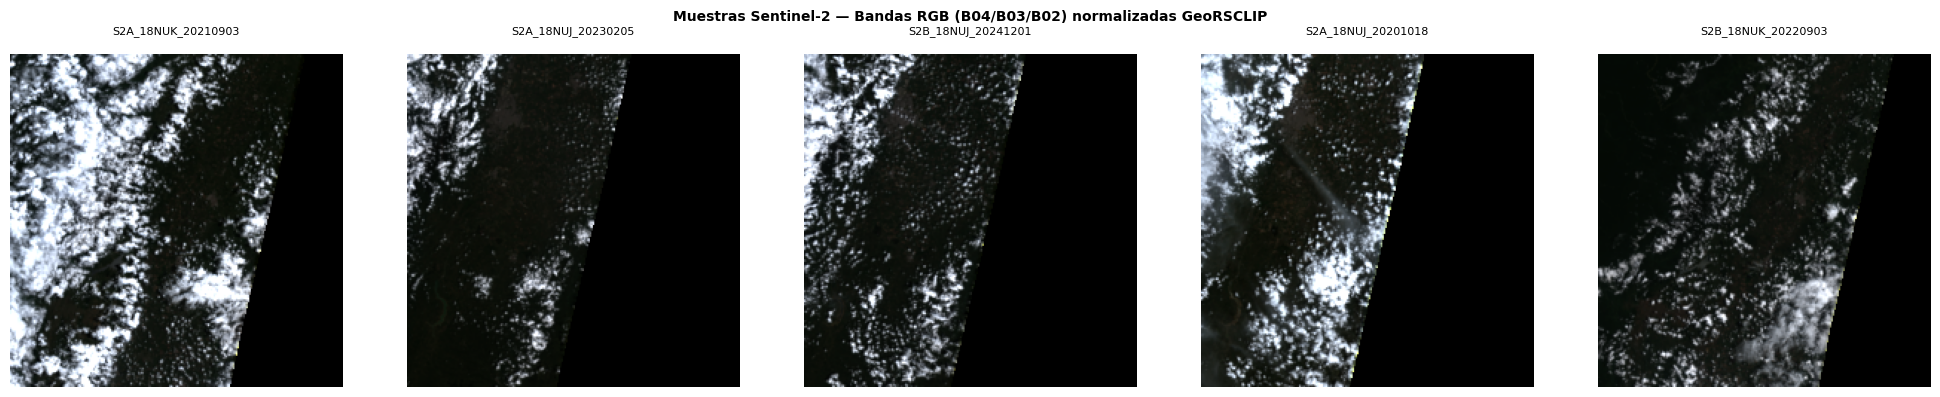

Gráfico guardado: muestras_s2_rgb.png


In [16]:
def denormalize_rgb(tensor_4c: np.ndarray) -> np.ndarray:
    """
    Invierte la normalización GeoRSCLIP para visualización.
    Recibe (4, 224, 224), devuelve (224, 224, 3) uint8 (R,G,B).
    """
    rgb = tensor_4c[:3].copy()   # (3, 224, 224)
    for i in range(3):
        rgb[i] = rgb[i] * CLIP_STD[i] + CLIP_MEAN[i]
    rgb = np.clip(rgb, 0, 1)
    rgb = (rgb * 255).astype(np.uint8)
    return np.transpose(rgb, (1, 2, 0))   # (224, 224, 3)


# ── Cargar 5 muestras aleatorias desde Zarr ────────────────────────────────
store_vis = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="r")

images     = store_vis["images"]
meta_fecha = store_vis["fecha"]
meta_ids   = store_vis["escena_id"]

n_total = images.shape[0]
indices   = np.random.choice(n_total, size=min(5, n_total), replace=False)

fig, axes = plt.subplots(1, len(indices), figsize=(4 * len(indices), 4))
if len(indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, indices):
    tensor = images[idx]                        # (4, 224, 224)
    img    = denormalize_rgb(tensor)
    fecha  = store_vis["fecha"][idx]
    esc_id = store_vis["escena_id"][idx]

    ax.imshow(img)
    ax.set_title(f"{esc_id[:18]}\n{fecha}", fontsize=8)
    ax.axis("off")

fig.suptitle("Muestras Sentinel-2 — Bandas RGB (B04/B03/B02) normalizadas GeoRSCLIP",
             fontsize=10, fontweight="bold")
plt.tight_layout()
plt.savefig("muestras_s2_rgb.png", dpi=150, bbox_inches="tight")
plt.show()
print("Gráfico guardado: muestras_s2_rgb.png")

## 7 · Hash MD5 del Zarr (Trazabilidad)

In [18]:
def md5_file(path: Path, chunk_size: int = 1 << 20) -> str:
    """Calcula MD5 de un archivo grande por chunks."""
    
    h = hashlib.md5()

    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(chunk_size), b""):
            h.update(chunk)

    return h.hexdigest()


# ── Abrir grupo Zarr ───────────────────────────────────────────────────────
store_vis = zarr.open_group(str(ZARR_OUTPUT_PATH), mode="r")

images = store_vis["images"]

# ── MD5 de metadata ────────────────────────────────────────────────────────
zarr_meta = ZARR_OUTPUT_PATH / ".zmetadata"

if zarr_meta.exists():
    md5 = md5_file(zarr_meta)
    print(f"MD5 (.zmetadata): {md5}")
else:
    md5 = "N/A"


summary = {
    "zarr_path"     : str(ZARR_OUTPUT_PATH),
    "n_escenas"     : processed,
    "shape"         : list(images.shape),
    "bandas"        : TARGET_BANDS,
    "tile_size"     : TILE_SIZE,
    "normalizacion" : "GeoRSCLIP (CLIP_MEAN/STD)",
    "md5_metadata"  : md5,
}

with open("etl_s2_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("\n── Resumen ETL ─────────────────────────────────")

print(json.dumps(summary, indent=2))

MD5 (.zmetadata): d28ded152588d43acdf4f1f42579110c

── Resumen ETL ─────────────────────────────────
{
  "zarr_path": "D:\\analitica\\procesado_zarr\\sentinel2_224.zarr",
  "n_escenas": 363,
  "shape": [
    363,
    4,
    224,
    224
  ],
  "bandas": [
    "B02",
    "B03",
    "B04",
    "B08"
  ],
  "tile_size": 224,
  "normalizacion": "GeoRSCLIP (CLIP_MEAN/STD)",
  "md5_metadata": "d28ded152588d43acdf4f1f42579110c"
}


## 8 · Cerrar Clúster

In [20]:
client.close()
cluster.close()
print("Clúster Dask cerrado. ETL Fase 1 finalizado exitosamente.")

Clúster Dask cerrado. ETL Fase 1 finalizado exitosamente.


reparar el metadata bbox

In [25]:
from pathlib import Path
from pyproj import Transformer
import numpy as np
import rasterio
import zarr


# ─────────────────────────────────────────────────────────────
# Abrir Zarr
# ─────────────────────────────────────────────────────────────

ZARR_PATH = Path(
    r"D:\analitica\procesado_zarr\sentinel2_224.zarr"
)

store = zarr.open(str(ZARR_PATH), mode="a")


# ─────────────────────────────────────────────────────────────
# Buscar TIFFs Sentinel-2
# ─────────────────────────────────────────────────────────────

S2_ROOT = Path(r"D:\analitica\sentinel2")

s2_files = sorted(
    S2_ROOT.rglob("*.tif")
)

print(f"TIFFs encontrados: {len(s2_files)}")


# ─────────────────────────────────────────────────────────────
# Función → bounds en WGS84
# ─────────────────────────────────────────────────────────────

def raster_bounds_wgs84(path):

    with rasterio.open(path) as src:

        bounds = src.bounds
        crs = src.crs

        transformer = Transformer.from_crs(
            crs,
            "EPSG:4326",
            always_xy=True
        )

        lon_min, lat_min = transformer.transform(
            bounds.left,
            bounds.bottom
        )

        lon_max, lat_max = transformer.transform(
            bounds.right,
            bounds.top
        )

    return [
        lon_min,
        lat_min,
        lon_max,
        lat_max
    ]


# ─────────────────────────────────────────────────────────────
# Recalcular bbox
# ─────────────────────────────────────────────────────────────

bbox_fixed = []

for path in s2_files[:363]:

    try:

        bbox = raster_bounds_wgs84(path)

        bbox_fixed.append(bbox)

    except Exception as e:

        print(f"Error: {path}")
        print(e)

bbox_fixed = np.array(
    bbox_fixed,
    dtype=np.float64
)

print("\nShape bbox:")
print(bbox_fixed.shape)

print("\nEjemplos bbox:")
print(bbox_fixed[:5])


# ─────────────────────────────────────────────────────────────
# Sobrescribir bbox en Zarr
# ─────────────────────────────────────────────────────────────

store["bbox"][:] = bbox_fixed

print("\n✅ bbox actualizado correctamente.")

TIFFs encontrados: 3630

Shape bbox:
(363, 4)

Ejemplos bbox:
[[-76.7989276    2.62439197 -75.81218605   3.61869306]
 [-76.7989276    2.62439197 -75.81218605   3.61869306]
 [-76.7989276    2.62439197 -75.81218605   3.61869306]
 [-76.7989276    2.62439197 -75.81218605   3.61869306]
 [-76.7989276    2.62439197 -75.81218605   3.61869306]]

✅ bbox actualizado correctamente.


In [26]:
bboxes = store["bbox"][:]

centroid_lon = (bboxes[:, 0] + bboxes[:, 2]) / 2
centroid_lat = (bboxes[:, 1] + bboxes[:, 3]) / 2

print(centroid_lon[:5])
print(centroid_lat[:5])

[-76.30555683 -76.30555683 -76.30555683 -76.30555683 -76.30555683]
[3.12154252 3.12154252 3.12154252 3.12154252 3.12154252]
